# Wawer bioactive compounds (CDRP) → AnnData

The CDRP bioactive compound screen ([`cpg0012`](https://broadinstitute.github.io/cellpainting-gallery/), also idr0016, BBBC036, BBBC047), 30,000 compounds in U2OS. The largest per-plate dataset here at 153,022 wells, and unlike most it keeps a workable feature set across every batch. Twenty-six wells are duplicated under the same batch, plate and well identifier, so the default index is kept.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_all.csv.gz" \
  s3://cellpainting-gallery/cpg0012-wawer-bioactivecompoundprofiling/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0012-wawer-bioactivecompoundprofiling/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

405 plates


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2}, on_column_mismatch="intersect")
adata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 153022 × 797
    obs: 'broad_sample', 'mmoles_per_liter', 'solvent', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'cpd_name', 'cpd_name_type', 'cpd_sample_id', 'pert_type', 'control_type', 'dos_library', 'source_name', 'chemist_name', 'vendor_catalog_id', 'user_comment', 'smiles', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


for column in present(["batch", "Plate", "pert_type", "cpd_name_type", "dos_library"]):
    adata.obs[column] = adata.obs[column].astype("category")
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_DNA,image,granularity,dna,NaN,1
Image_Granularity_10_ER,image,granularity,er,NaN,1
Image_Granularity_10_RNA,image,granularity,rna,NaN,1
Image_Granularity_11_AGP,image,granularity,agp,NaN,1
...,...,...,...,...,...
Nuclei_Texture_SumEntropy_ER_10_01_256,nuclei,texture,er,NaN,1
Nuclei_Texture_SumEntropy_RNA_10_01_256,nuclei,texture,rna,NaN,1
Nuclei_Texture_SumVariance_AGP_10_03_256,nuclei,texture,agp,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["pert_type", "cpd_name_type"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

153,022 wells x 781 features
non-finite: 0 | max|x|: 70054.0

pert_type:
pert_type
trt        126514
control     26508

cpd_name_type:
cpd_name_type
BROAD_CPD_ID      108421
<NA>               26527
INN                 5939
primary-common      5516
to-be-curated       4262
common              1816


In [6]:
adata.write_h5ad(PROFILES.parent / "wawer.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["batch", "Plate", "pert_type", "dos_library"]))

,observed,baseline,ratio
covariate,,,
Plate,0.036,0.002,14.22
pert_type,0.757,0.714,1.06
dos_library,0.277,0.079,3.52


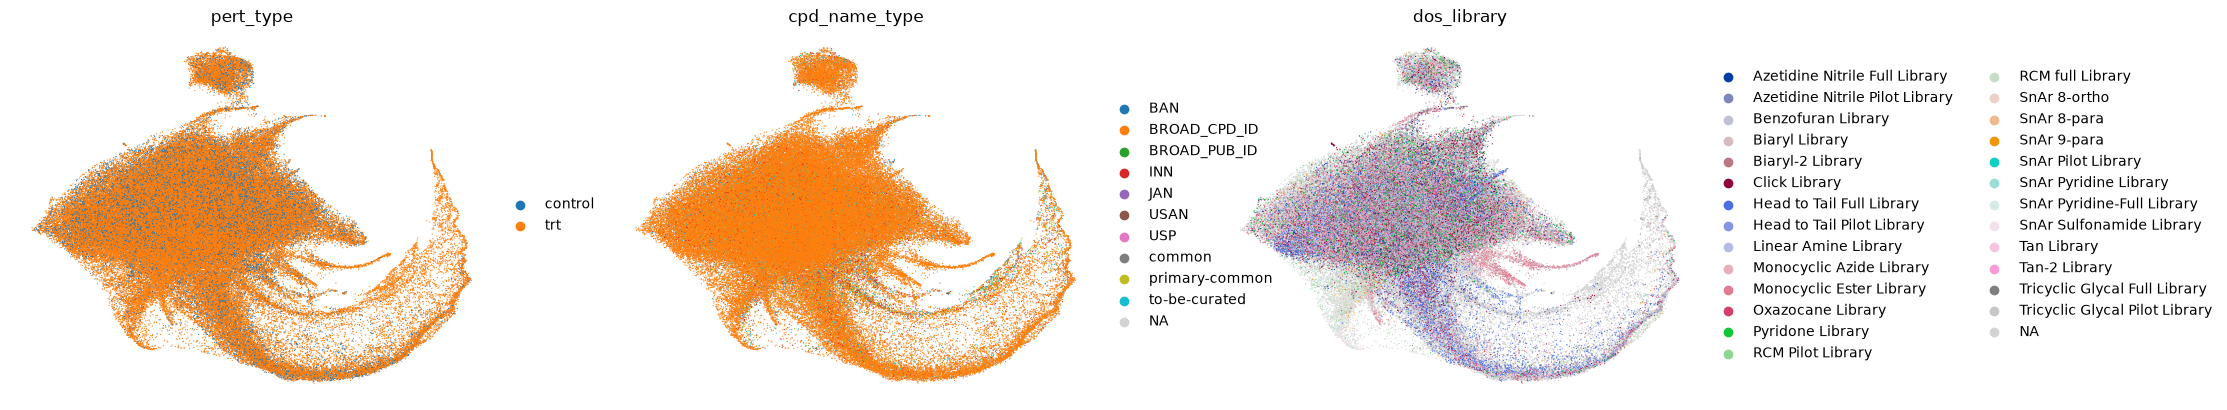

In [9]:
sc.pl.umap(adata, color=present(["pert_type", "cpd_name_type", "dos_library"])[:3], ncols=3, frameon=False, size=3)